# Jisoo's Data KF Estimation Analysis


This notebook loads Jisoo's step and white-noise neural recording data, prepares orange-light training/evaluation trials, fits an SSM model, and evaluates regular versus parameter-adaptive Kalman filtering on continuous step-file segments. 

All helper functions needed for loading data, fitting parameter extraction, continuous filtering, metric tables, and plotting are included in the notebook. The latent dimension is fixed at `SSM_FIT_D = 6`, which was chosen from a parameter sweep that is not included here (I previously loaded a sweep results file saved from another notebook, but I lost that notebook). The final sections manually set `Q`, `Qmu`, and `R` scales (R was not changed), run the filters over the continuous recordings, slice results back into trials, and summarize performance with covariance plots, trial-average traces, and grouped RMSE statistics.


## Setup


In [24]:
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence
import pickle
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
from IPython.display import display
from scipy.linalg import solve_discrete_are

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "NDACPython":
    project_candidate = PROJECT_DIR / "NDACPython"
    if project_candidate.exists():
        PROJECT_DIR = project_candidate

python_tag = f"lib.win-amd64-cpython-{sys.version_info.major}{sys.version_info.minor}"
ssm_build_candidates = sorted((PROJECT_DIR / "ssm" / "build").glob("lib.win-amd64-cpython-*"))
preferred_build_dir = PROJECT_DIR / "ssm" / "build" / python_tag
import_dirs = []
if preferred_build_dir.exists():
    import_dirs.append(preferred_build_dir)
for candidate in ssm_build_candidates:
    if candidate not in import_dirs:
        import_dirs.append(candidate)
import_dirs.extend([
    PROJECT_DIR,
    PROJECT_DIR / "ssm",
    PROJECT_DIR / "SIPPY",
])
for candidate in reversed(import_dirs):
    candidate_str = str(candidate)
    if candidate.exists() and candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

from main1 import OnlineSLDSModel


## Configuration


In [25]:
DATA_DIR = (PROJECT_DIR.parent / "JH017_1_Data4TestingKF").resolve()

FITTED_CHANNEL_LABELS = [25]
FIT_CHANNEL_INDICES = [int(channel) - 1 for channel in FITTED_CHANNEL_LABELS]

# D=6 was selected from a parameter sweep that is not included in this notebook.
SSM_FIT_D = 6
SSM_FIT_NUM_ITERS = 25

TRAIN_WHITE_NOISE_SEC = 3.5
MODEL_TRAIN_FIELD = "y_rate_hz"
FILTER_MEASUREMENT_FIELD = "y_rate_hz"
REFERENCE_TRACE_FIELD = "y_rate_hz"

ORANGE_INPUT_INDEX = 1
INIT_COV_SCALE = 1e-2


## Data Loading Helpers


In [26]:
RAW_FS = 1000
NEURAL_RECORDING_FS = 500
NEURAL_UPSAMPLE_FACTOR = RAW_FS // NEURAL_RECORDING_FS
BIN_MS = 10
BIN_SAMPLES = RAW_FS * BIN_MS // 1000
BIN_FS = RAW_FS // BIN_SAMPLES
DT = 1.0 / BIN_FS
SMOOTH_STD_MS = 25.0

STEP_FILE_NUMBERS = tuple(range(5, 15))
WHITE_NOISE_FILE_NUMBER = 16
STEP_TRIAL_SEC = 2.0
STEP_PRE_SEC = 1.0
STEP_POST_SEC = 1.0
WHITE_NOISE_TRIAL_SEC = 5.0
NEURAL_CHANNEL_SLICE = slice(5, 37)


@dataclass
class TrialData:
    kind: str
    file_number: int
    trial_index: int
    raw_start: int
    raw_stop: int
    dt: float
    time_s: np.ndarray
    u_raw: np.ndarray
    y_raw: np.ndarray
    u: np.ndarray
    y: np.ndarray
    y_rate_raw_hz: np.ndarray
    y_rate_hz: np.ndarray
    blue_level: float | None = None
    orange_level: float | None = None
    stim_start_bin: int | None = None
    stim_stop_bin: int | None = None




def _load_block_array(file_path: Path) -> np.ndarray:
    with h5py.File(file_path, "r") as handle:
        dataset = handle["/Trial1/Synchronous Data/Channel Data"]
        return np.stack(dataset[:]).astype(np.float64, copy=False)


def _trigger_rising_edges(trigger: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    binary = (np.asarray(trigger, dtype=float) > threshold).astype(int)
    return np.where(np.diff(binary) == 1)[0] + 1


def _bin_mean(x: np.ndarray, bin_samples: int = BIN_SAMPLES) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    usable = (x.shape[0] // bin_samples) * bin_samples
    x = x[:usable]
    new_shape = (usable // bin_samples, bin_samples) + x.shape[1:]
    return x.reshape(new_shape).mean(axis=1)


def _bin_sum(x: np.ndarray, bin_samples: int = BIN_SAMPLES) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    usable = (x.shape[0] // bin_samples) * bin_samples
    x = x[:usable]
    new_shape = (usable // bin_samples, bin_samples) + x.shape[1:]
    return x.reshape(new_shape).sum(axis=1)


def _recover_2ms_spike_counts_from_upsampled_trace(
    raw_spikes: np.ndarray,
    upsample_factor: int = NEURAL_UPSAMPLE_FACTOR,
) -> np.ndarray:
    x = np.asarray(raw_spikes, dtype=np.float64)
    if upsample_factor <= 0:
        raise ValueError("upsample_factor must be positive.")
    usable = (x.shape[0] // upsample_factor) * upsample_factor
    x = x[:usable]
    new_shape = (usable // upsample_factor, upsample_factor) + x.shape[1:]
    # The 1000 Hz neural trace stores an upsampled version of the underlying
    # 500 Hz signal. Summing each adjacent pair recovers the spike count in the
    # original 2 ms recording bin.
    return x.reshape(new_shape).sum(axis=1)


def _gaussian_kernel(std_bins: float) -> np.ndarray:
    if std_bins <= 0:
        return np.array([1.0], dtype=np.float64)
    half_width = int(np.ceil(3.0 * std_bins))
    offsets = np.arange(-half_width, half_width + 1, dtype=np.float64)
    kernel = np.exp(-0.5 * (offsets / std_bins) ** 2)
    kernel /= kernel.sum()
    return kernel


def smooth_firing_rate_from_raw_spikes(
    raw_spikes: np.ndarray,
    raw_fs: int = RAW_FS,
    bin_ms: int = BIN_MS,
    smooth_std_ms: float = SMOOTH_STD_MS,
) -> tuple[np.ndarray, np.ndarray]:
    counts_per_bin, firing_rate_hz = binned_firing_rate_from_raw_spikes(
        raw_spikes=raw_spikes,
        raw_fs=raw_fs,
        bin_ms=bin_ms,
    )
    kernel = _gaussian_kernel(float(smooth_std_ms) / float(bin_ms))
    smoothed_firing_rate_hz = np.apply_along_axis(
        lambda col: np.convolve(col, kernel, mode="same"),
        0,
        np.asarray(firing_rate_hz, dtype=np.float64),
    )
    return counts_per_bin, smoothed_firing_rate_hz


def binned_firing_rate_from_raw_spikes(
    raw_spikes: np.ndarray,
    raw_fs: int = RAW_FS,
    bin_ms: int = BIN_MS,
) -> tuple[np.ndarray, np.ndarray]:
    if raw_fs % NEURAL_RECORDING_FS != 0:
        raise ValueError(
            f"Expected raw_fs={raw_fs} to be an integer multiple of the 500 Hz neural recording rate."
        )
    recovered_2ms_counts = _recover_2ms_spike_counts_from_upsampled_trace(
        raw_spikes,
        upsample_factor=raw_fs // NEURAL_RECORDING_FS,
    )
    neural_bin_samples = int(round(float(bin_ms) * NEURAL_RECORDING_FS / 1000.0))
    if neural_bin_samples <= 0:
        raise ValueError("bin_ms is too small for the 500 Hz neural sampling rate.")
    bin_width_s = float(bin_ms) / 1000.0
    # Math:
    # 1. Recover 2 ms counts from the upsampled 1000 Hz trace:
    #       c[k] = y_raw[2k] + y_raw[2k + 1]
    # 2. Form 10 ms counts by summing five consecutive 2 ms bins:
    #       b[m] = sum_{j=0}^{4} c[5m + j]
    # 3. Convert those 10 ms counts to firing rate in spikes/s:
    #       r[m] = b[m] / 0.01
    counts_per_bin = _bin_sum(recovered_2ms_counts, bin_samples=neural_bin_samples)
    firing_rate_hz = counts_per_bin / bin_width_s
    return counts_per_bin, firing_rate_hz


def _load_step_order(base_dir: Path) -> np.ndarray:
    order_mat = scipy.io.loadmat(base_dir / "RTXI_BiPOLES_holdRandom_Both_0159_opto_order.mat")
    return np.asarray(order_mat["opto_order_BO"], dtype=np.float64)


def _make_trial(
    block: np.ndarray,
    kind: str,
    file_number: int,
    trial_index: int,
    raw_start: int,
    raw_stop: int,
    event_raw_start: int | None = None,
    event_raw_stop: int | None = None,
    blue_level: float | None = None,
    orange_level: float | None = None,
) -> TrialData:
    window = np.asarray(block[raw_start:raw_stop], dtype=np.float64)
    u_raw = window[:, [2, 3]].copy()
    if kind == "white_noise":
        # Jisoo wants white-noise blue input treated as zero even though the raw
        # file stores the same waveform in both input columns.
        u_raw[:, 0] = 0.0
    y_raw = window[:, NEURAL_CHANNEL_SLICE]
    u = _bin_mean(u_raw)
    y, y_rate_hz = smooth_firing_rate_from_raw_spikes(y_raw)
    _, y_rate_raw_hz = binned_firing_rate_from_raw_spikes(y_raw)
    if event_raw_start is None:
        time_s = np.arange(y.shape[0], dtype=np.float64) * DT
        stim_start_bin = None
        stim_stop_bin = None
    else:
        stim_start_bin = int(round((event_raw_start - raw_start) / BIN_SAMPLES))
        if event_raw_stop is None:
            stim_stop_bin = None
        else:
            stim_stop_bin = int(round((event_raw_stop - raw_start) / BIN_SAMPLES))
        time_s = (np.arange(y.shape[0], dtype=np.float64) - stim_start_bin) * DT
    return TrialData(
        kind=kind,
        file_number=int(file_number),
        trial_index=int(trial_index),
        raw_start=int(raw_start),
        raw_stop=int(raw_stop),
        dt=DT,
        time_s=time_s,
        u_raw=u_raw,
        y_raw=y_raw,
        u=u,
        y=y,
        y_rate_raw_hz=y_rate_raw_hz,
        y_rate_hz=y_rate_hz,
        blue_level=blue_level,
        orange_level=orange_level,
        stim_start_bin=stim_start_bin,
        stim_stop_bin=stim_stop_bin,
    )


def load_jisoo_dataset(base_dir: str | Path) -> dict[str, list[TrialData]]:
    base_path = Path(base_dir)
    step_order = _load_step_order(base_path)
    step_trials: list[TrialData] = []
    white_noise_trials: list[TrialData] = []

    step_samples = int(round(STEP_TRIAL_SEC * RAW_FS))
    step_pre_samples = int(round(STEP_PRE_SEC * RAW_FS))
    step_post_samples = int(round(STEP_POST_SEC * RAW_FS))
    white_noise_samples = int(round(WHITE_NOISE_TRIAL_SEC * RAW_FS))

    for file_number in STEP_FILE_NUMBERS:
        block = _load_block_array(base_path / f"{file_number}.h5")
        starts = _trigger_rising_edges(block[:, 0])
        if len(starts) != step_order.shape[1]:
            raise ValueError(
                f"Expected {step_order.shape[1]} step trials in {file_number}.h5, found {len(starts)}."
            )

        for trial_index, start in enumerate(starts):
            raw_start = max(int(start - step_pre_samples), 0)
            raw_stop = min(int(start + step_samples + step_post_samples), block.shape[0])
            step_trials.append(
                _make_trial(
                    block=block,
                    kind="step",
                    file_number=file_number,
                    trial_index=trial_index,
                    raw_start=raw_start,
                    raw_stop=raw_stop,
                    event_raw_start=int(start),
                    event_raw_stop=int(start + step_samples),
                    blue_level=float(step_order[0, trial_index]),
                    orange_level=float(step_order[1, trial_index]),
                )
            )

    block = _load_block_array(base_path / f"{WHITE_NOISE_FILE_NUMBER}.h5")
    starts = _trigger_rising_edges(block[:, 0])
    if len(starts) != 13:
        raise ValueError(f"Expected 13 white-noise trials in {WHITE_NOISE_FILE_NUMBER}.h5, found {len(starts)}.")

    for trial_index, start in enumerate(starts):
        white_noise_trials.append(
            _make_trial(
                block=block,
                kind="white_noise",
                file_number=WHITE_NOISE_FILE_NUMBER,
                trial_index=trial_index,
                raw_start=int(start),
                raw_stop=int(start + white_noise_samples),
            )
        )

    return {"step_trials": step_trials, "white_noise_trials": white_noise_trials}


def build_sample_segment(base_dir: str | Path, file_number: int, raw_start: int, raw_stop: int) -> TrialData:
    base_path = Path(base_dir)
    block = _load_block_array(base_path / f"{int(file_number)}.h5")
    return _make_trial(
        block=block,
        kind="segment",
        file_number=int(file_number),
        trial_index=-1,
        raw_start=int(raw_start),
        raw_stop=int(raw_stop),
    )


## Analysis and Plot Helpers


In [27]:
FILTER_COLORS = {
    "observed": "black",
    "regular_kf": "tab:blue",
    "para_adapt_kf": "tab:orange",
}


def compute_rmse(observed: np.ndarray, estimated: np.ndarray) -> float:
    observed = np.asarray(observed, dtype=float)
    estimated = np.asarray(estimated, dtype=float)
    return float(np.sqrt(np.mean((observed - estimated) ** 2)))


def compute_bias(observed: np.ndarray, estimated: np.ndarray) -> float:
    observed = np.asarray(observed, dtype=float)
    estimated = np.asarray(estimated, dtype=float)
    return float(np.mean(estimated - observed))


def stim_slice(result: dict) -> slice:
    start = int(result["stim_start_bin"])
    stop = int(result["stim_stop_bin"])
    return slice(start, stop)


def build_batch_tables(step_results: Sequence[dict]) -> tuple[pd.DataFrame, pd.DataFrame]:
    if not step_results:
        raise ValueError("step_results is empty.")

    batch_rows = []
    avg_rows = []
    for result in step_results:
        stim_window = stim_slice(result)
        obs = np.asarray(result["obs"], dtype=float)
        kf_yhat = np.asarray(result["kf_yhat"], dtype=float)
        para_yhat = np.asarray(result["para_yhat"], dtype=float)

        per_channel_kf_rmse = np.sqrt(np.mean((obs[stim_window] - kf_yhat[stim_window]) ** 2, axis=0))
        per_channel_para_rmse = np.sqrt(np.mean((obs[stim_window] - para_yhat[stim_window]) ** 2, axis=0))
        per_channel_kf_bias = np.mean(kf_yhat[stim_window] - obs[stim_window], axis=0)
        per_channel_para_bias = np.mean(para_yhat[stim_window] - obs[stim_window], axis=0)
        kf_bias_stim = compute_bias(obs[stim_window], kf_yhat[stim_window])
        para_bias_stim = compute_bias(obs[stim_window], para_yhat[stim_window])
        batch_rows.append(
            {
                "file_number": int(result["file_number"]),
                "trial_index": int(result["trial_index"]),
                "blue_level": float(result["blue_level"]),
                "orange_level": float(result["orange_level"]),
                "n_channels": int(obs.shape[1]),
                "kf_rmse_stim": compute_rmse(obs[stim_window], kf_yhat[stim_window]),
                "para_rmse_stim": compute_rmse(obs[stim_window], para_yhat[stim_window]),
                "rmse_gain_stim_kf_minus_para": compute_rmse(obs[stim_window], kf_yhat[stim_window])
                - compute_rmse(obs[stim_window], para_yhat[stim_window]),
                "kf_bias_stim": kf_bias_stim,
                "para_bias_stim": para_bias_stim,
                "kf_squared_bias_stim": float(kf_bias_stim**2),
                "para_squared_bias_stim": float(para_bias_stim**2),
                "bias_gain_stim_abs_kf_minus_para": float(abs(kf_bias_stim) - abs(para_bias_stim)),
                "kf_rmse_stim_by_channel": per_channel_kf_rmse,
                "para_rmse_stim_by_channel": per_channel_para_rmse,
                "kf_bias_stim_by_channel": per_channel_kf_bias,
                "para_bias_stim_by_channel": per_channel_para_bias,
                "kf_squared_bias_stim_by_channel": per_channel_kf_bias**2,
                "para_squared_bias_stim_by_channel": per_channel_para_bias**2,
            }
        )

    batch_df = pd.DataFrame(batch_rows).sort_values(
        ["orange_level", "blue_level", "file_number", "trial_index"],
        ignore_index=True,
    )

    grouped = batch_df.groupby(["orange_level", "blue_level"], sort=True)
    for (orange_level, blue_level), combo_df in grouped:
        combo_results = [
            result
            for result in step_results
            if float(result["orange_level"]) == float(orange_level) and float(result["blue_level"]) == float(blue_level)
        ]
        inputs_stack = np.stack([np.asarray(result["inputs"], dtype=float) for result in combo_results], axis=0)
        obs_stack = np.stack([np.asarray(result["obs"], dtype=float) for result in combo_results], axis=0)
        kf_yhat_stack = np.stack([np.asarray(result["kf_yhat"], dtype=float) for result in combo_results], axis=0)
        para_yhat_stack = np.stack([np.asarray(result["para_yhat"], dtype=float) for result in combo_results], axis=0)
        kf_xhat_stack = np.stack([np.asarray(result["kf_xhat"], dtype=float) for result in combo_results], axis=0)
        para_xhat_stack = np.stack([np.asarray(result["para_xhat"], dtype=float) for result in combo_results], axis=0)
        time_s = np.asarray(combo_results[0]["time_s"], dtype=float)
        stim_window = stim_slice(combo_results[0])

        mean_obs = obs_stack.mean(axis=0)
        mean_kf_yhat = kf_yhat_stack.mean(axis=0)
        mean_para_yhat = para_yhat_stack.mean(axis=0)
        mean_kf_xhat = kf_xhat_stack.mean(axis=0)
        mean_para_xhat = para_xhat_stack.mean(axis=0)

        avg_rows.append(
            {
                "orange_level": float(orange_level),
                "blue_level": float(blue_level),
                "n_trials": int(len(combo_results)),
                "time_s": time_s,
                "stim_start_bin": int(combo_results[0]["stim_start_bin"]),
                "stim_stop_bin": int(combo_results[0]["stim_stop_bin"]),
                "input_mean": inputs_stack.mean(axis=0),
                "input_std": inputs_stack.std(axis=0),
                "y_observed_mean": mean_obs,
                "y_observed_std": obs_stack.std(axis=0),
                "kf_yhat_mean": mean_kf_yhat,
                "kf_yhat_std": kf_yhat_stack.std(axis=0),
                "para_yhat_mean": mean_para_yhat,
                "para_yhat_std": para_yhat_stack.std(axis=0),
                "kf_xhat_mean": mean_kf_xhat,
                "kf_xhat_std": kf_xhat_stack.std(axis=0),
                "para_xhat_mean": mean_para_xhat,
                "para_xhat_std": para_xhat_stack.std(axis=0),
                "kf_rmse_stim_mean": float(combo_df["kf_rmse_stim"].mean()),
                "para_rmse_stim_mean": float(combo_df["para_rmse_stim"].mean()),
                "rmse_gain_stim_mean_kf_minus_para": float(combo_df["rmse_gain_stim_kf_minus_para"].mean()),
                "kf_bias_stim_mean": float(combo_df["kf_bias_stim"].mean()),
                "para_bias_stim_mean": float(combo_df["para_bias_stim"].mean()),
                "kf_squared_bias_stim_mean": float(combo_df["kf_squared_bias_stim"].mean()),
                "para_squared_bias_stim_mean": float(combo_df["para_squared_bias_stim"].mean()),
                "bias_gain_stim_abs_mean_kf_minus_para": float(combo_df["bias_gain_stim_abs_kf_minus_para"].mean()),
                "kf_rmse_stim_by_channel_mean": np.mean(np.stack(combo_df["kf_rmse_stim_by_channel"].to_list()), axis=0),
                "para_rmse_stim_by_channel_mean": np.mean(
                    np.stack(combo_df["para_rmse_stim_by_channel"].to_list()),
                    axis=0,
                ),
                "kf_bias_stim_by_channel_mean": np.mean(np.stack(combo_df["kf_bias_stim_by_channel"].to_list()), axis=0),
                "para_bias_stim_by_channel_mean": np.mean(
                    np.stack(combo_df["para_bias_stim_by_channel"].to_list()),
                    axis=0,
                ),
                "kf_squared_bias_stim_by_channel_mean": np.mean(
                    np.stack(combo_df["kf_squared_bias_stim_by_channel"].to_list()),
                    axis=0,
                ),
                "para_squared_bias_stim_by_channel_mean": np.mean(
                    np.stack(combo_df["para_squared_bias_stim_by_channel"].to_list()),
                    axis=0,
                ),
                "kf_rmse_of_mean_trace_stim": compute_rmse(mean_obs[stim_window], mean_kf_yhat[stim_window]),
                "para_rmse_of_mean_trace_stim": compute_rmse(mean_obs[stim_window], mean_para_yhat[stim_window]),
                "kf_bias_of_mean_trace_stim": compute_bias(mean_obs[stim_window], mean_kf_yhat[stim_window]),
                "para_bias_of_mean_trace_stim": compute_bias(mean_obs[stim_window], mean_para_yhat[stim_window]),
                "kf_squared_bias_of_mean_trace_stim": float(
                    compute_bias(mean_obs[stim_window], mean_kf_yhat[stim_window]) ** 2
                ),
                "para_squared_bias_of_mean_trace_stim": float(
                    compute_bias(mean_obs[stim_window], mean_para_yhat[stim_window]) ** 2
                ),
            }
        )

    batch_df_av = pd.DataFrame(avg_rows).sort_values(["orange_level", "blue_level"], ignore_index=True)
    return batch_df, batch_df_av


def filter_batch_df_for_light_mode(batch_df: pd.DataFrame, light_mode: str) -> pd.DataFrame:
    mode = str(light_mode).upper()
    orange_levels = batch_df["orange_level"].isin([0.0, 1.0, 5.0, 9.0])
    blue_levels = batch_df["blue_level"].isin([0.0, 1.0, 5.0, 9.0])
    if mode == "ORANGE":
        mask = (batch_df["blue_level"] == 0.0) & orange_levels
    elif mode == "BLUE":
        mask = (batch_df["orange_level"] == 0.0) & blue_levels
    elif mode == "BOTH":
        mask = orange_levels & blue_levels
    else:
        raise ValueError("light_mode must be 'ORANGE', 'BLUE', or 'BOTH'.")
    return batch_df.loc[mask].copy()


def plot_model_matrix_grid(
    matrix: np.ndarray,
    title: str,
    cmap: str = "coolwarm",
    value_fmt: str = ".3f",
    ax: plt.Axes | None = None,
) -> plt.Axes:
    values = np.asarray(matrix, dtype=float)
    if values.ndim != 2:
        raise ValueError(f"{title} must be 2D after squeezing, got shape {values.shape}.")
    created_fig = False
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3))
        created_fig = True
    image = ax.imshow(values, cmap=cmap, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_xticks(np.arange(values.shape[1]))
    ax.set_yticks(np.arange(values.shape[0]))
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            ax.text(col, row, format(values[row, col], value_fmt), ha="center", va="center", color="black")
    colorbar = ax.figure.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label("Value")
    if created_fig:
        ax.figure.tight_layout()
    return ax


def plot_combo_trial_average_summary(
    combo_results: Sequence[dict],
    channel_labels: Sequence[int],
) -> plt.Figure:
    if not combo_results:
        raise ValueError("combo_results is empty.")

    first = combo_results[0]
    time_s = np.asarray(first["time_s"], dtype=float)
    stim_window = stim_slice(first)

    input_stack = np.stack([np.asarray(result["inputs"], dtype=float) for result in combo_results], axis=0)
    obs_stack = np.stack([np.asarray(result["obs"], dtype=float) for result in combo_results], axis=0)
    kf_xhat_stack = np.stack([np.asarray(result["kf_xhat"], dtype=float) for result in combo_results], axis=0)
    para_xhat_stack = np.stack([np.asarray(result["para_xhat"], dtype=float) for result in combo_results], axis=0)
    muhat_stack = np.stack([np.asarray(result["muhat"], dtype=float) for result in combo_results], axis=0)
    kf_yhat_stack = np.stack([np.asarray(result["kf_yhat"], dtype=float) for result in combo_results], axis=0)
    para_yhat_stack = np.stack([np.asarray(result["para_yhat"], dtype=float) for result in combo_results], axis=0)

    input_mean = input_stack.mean(axis=0)
    input_std = input_stack.std(axis=0)
    obs_mean = obs_stack.mean(axis=0)
    obs_std = obs_stack.std(axis=0)
    kf_xhat_mean = kf_xhat_stack.mean(axis=0)
    kf_xhat_std = kf_xhat_stack.std(axis=0)
    para_xhat_mean = para_xhat_stack.mean(axis=0)
    para_xhat_std = para_xhat_stack.std(axis=0)
    muhat_mean = muhat_stack.mean(axis=0)
    muhat_std = muhat_stack.std(axis=0)
    kf_yhat_mean = kf_yhat_stack.mean(axis=0)
    kf_yhat_std = kf_yhat_stack.std(axis=0)
    para_yhat_mean = para_yhat_stack.mean(axis=0)
    para_yhat_std = para_yhat_stack.std(axis=0)

    kf_rmse = compute_rmse(obs_mean[stim_window], kf_yhat_mean[stim_window])
    para_rmse = compute_rmse(obs_mean[stim_window], para_yhat_mean[stim_window])

    fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True, constrained_layout=True)
    channel_cmap = plt.get_cmap("tab10")
    latent_cmap = plt.get_cmap("tab20")

    axes[0, 0].plot(time_s, input_mean[:, 1], color="tab:orange", linewidth=2.0, label="orange input")
    axes[0, 0].fill_between(
        time_s,
        input_mean[:, 1] - input_std[:, 1],
        input_mean[:, 1] + input_std[:, 1],
        color="tab:orange",
        alpha=0.25,
    )
    axes[0, 0].plot(time_s, input_mean[:, 0], color="tab:blue", linewidth=2.0, label="blue input")
    axes[0, 0].fill_between(
        time_s,
        input_mean[:, 0] - input_std[:, 0],
        input_mean[:, 0] + input_std[:, 0],
        color="tab:blue",
        alpha=0.25,
    )
    axes[0, 0].set_title("Input u")
    axes[0, 0].set_ylabel("Input")
    axes[0, 0].legend(loc="upper right", fontsize=8)

    for local_idx, channel_label in enumerate(channel_labels):
        color = channel_cmap(local_idx % 10)
        axes[0, 1].plot(time_s, obs_mean[:, local_idx], color=color, linewidth=1.8, label=f"ch{channel_label}")
        axes[0, 1].fill_between(
            time_s,
            obs_mean[:, local_idx] - obs_std[:, local_idx],
            obs_mean[:, local_idx] + obs_std[:, local_idx],
            color=color,
            alpha=0.25,
        )
    axes[0, 1].set_title("Observed y (raw rate)")
    axes[0, 1].set_ylabel("Hz")
    axes[0, 1].legend(loc="upper right", fontsize=7, ncol=2)

    for state_idx in range(kf_xhat_mean.shape[1]):
        color = latent_cmap(state_idx % 20)
        axes[1, 0].plot(time_s, kf_xhat_mean[:, state_idx], color=color, linewidth=1.6, label=f"x{state_idx + 1}")
        axes[1, 0].fill_between(
            time_s,
            kf_xhat_mean[:, state_idx] - kf_xhat_std[:, state_idx],
            kf_xhat_mean[:, state_idx] + kf_xhat_std[:, state_idx],
            color=color,
            alpha=0.2,
        )
    axes[1, 0].set_title("Estimated x (regular KF)")
    axes[1, 0].set_ylabel("State")
    axes[1, 0].legend(loc="upper right", fontsize=7, ncol=2)

    for local_idx, channel_label in enumerate(channel_labels):
        color = channel_cmap(local_idx % 10)
        axes[1, 1].plot(
            time_s,
            kf_yhat_mean[:, local_idx],
            color=color,
            linewidth=1.8,
            label=f"ch{channel_label}",
        )
        axes[1, 1].fill_between(
            time_s,
            kf_yhat_mean[:, local_idx] - kf_yhat_std[:, local_idx],
            kf_yhat_mean[:, local_idx] + kf_yhat_std[:, local_idx],
            color=color,
            alpha=0.25,
        )
    axes[1, 1].set_title(f"Estimated y (regular KF), mean-trace RMSE: {kf_rmse:.4f}")
    axes[1, 1].set_ylabel("Hz")
    axes[1, 1].legend(loc="upper right", fontsize=7, ncol=2)

    for state_idx in range(para_xhat_mean.shape[1]):
        color = latent_cmap(state_idx % 20)
        axes[2, 0].plot(time_s, para_xhat_mean[:, state_idx], color=color, linewidth=1.6, label=f"x{state_idx + 1}")
        axes[2, 0].fill_between(
            time_s,
            para_xhat_mean[:, state_idx] - para_xhat_std[:, state_idx],
            para_xhat_mean[:, state_idx] + para_xhat_std[:, state_idx],
            color=color,
            alpha=0.2,
        )
    axes[2, 0].set_title("Estimated x (para-adapt KF)")
    axes[2, 0].set_ylabel("State")
    axes[2, 0].legend(loc="upper right", fontsize=7, ncol=2)

    for local_idx, channel_label in enumerate(channel_labels):
        color = channel_cmap(local_idx % 10)
        axes[2, 1].plot(
            time_s,
            para_yhat_mean[:, local_idx],
            color=color,
            linewidth=1.8,
            label=f"ch{channel_label}",
        )
        axes[2, 1].fill_between(
            time_s,
            para_yhat_mean[:, local_idx] - para_yhat_std[:, local_idx],
            para_yhat_mean[:, local_idx] + para_yhat_std[:, local_idx],
            color=color,
            alpha=0.25,
        )
    axes[2, 1].set_title(f"Estimated y (para-adapt KF), mean-trace RMSE: {para_rmse:.4f}")
    axes[2, 1].set_ylabel("Hz")
    axes[2, 1].legend(loc="upper right", fontsize=7, ncol=2)

    for state_idx in range(muhat_mean.shape[1]):
        color = latent_cmap(state_idx % 20)
        axes[3, 0].plot(time_s, muhat_mean[:, state_idx], color=color, linewidth=1.6, label=f"mu_{state_idx + 1}")
        axes[3, 0].fill_between(
            time_s,
            muhat_mean[:, state_idx] - muhat_std[:, state_idx],
            muhat_mean[:, state_idx] + muhat_std[:, state_idx],
            color=color,
            alpha=0.2,
        )
    axes[3, 0].set_title("Estimated latent disturbance mu")
    axes[3, 0].set_ylabel("Hz offset")
    axes[3, 0].set_xlabel("Time (s)")
    axes[3, 0].legend(loc="upper right", fontsize=7, ncol=2)

    for local_idx, channel_label in enumerate(channel_labels):
        color = channel_cmap(local_idx % 10)
        axes[3, 1].plot(
            time_s,
            obs_mean[:, local_idx],
            color=color,
            linewidth=1.8,
            label=f"obs ch{channel_label}",
        )
        axes[3, 1].fill_between(
            time_s,
            obs_mean[:, local_idx] - obs_std[:, local_idx],
            obs_mean[:, local_idx] + obs_std[:, local_idx],
            color=color,
            alpha=0.12,
        )
        axes[3, 1].plot(
            time_s,
            para_yhat_mean[:, local_idx],
            color=color,
            linewidth=1.4,
            linestyle="-.",
            label=f"para ch{channel_label}",
        )
        axes[3, 1].fill_between(
            time_s,
            para_yhat_mean[:, local_idx] - para_yhat_std[:, local_idx],
            para_yhat_mean[:, local_idx] + para_yhat_std[:, local_idx],
            color=color,
            alpha=0.08,
        )
        axes[3, 1].plot(
            time_s,
            kf_yhat_mean[:, local_idx],
            color=color,
            linewidth=1.4,
            linestyle="--",
            label=f"kf ch{channel_label}",
        )
        axes[3, 1].fill_between(
            time_s,
            kf_yhat_mean[:, local_idx] - kf_yhat_std[:, local_idx],
            kf_yhat_mean[:, local_idx] + kf_yhat_std[:, local_idx],
            color=color,
            alpha=0.08,
        )
    axes[3, 1].set_title("Observed vs estimated y")
    axes[3, 1].set_ylabel("Hz")
    axes[3, 1].set_xlabel("Time (s)")
    axes[3, 1].legend(loc="upper right", fontsize=6, ncol=2)

    title_result = combo_results[0]
    fig.suptitle(
        "Trial-average filter summary"
        f" | orange={int(title_result['orange_level'])}, blue={int(title_result['blue_level'])}"
        f" | n_trials={len(combo_results)}"
        f" | gain={kf_rmse - para_rmse:.4f}",
        fontsize=13,
    )

    for ax in axes.flat:
        ax.grid(True, alpha=0.25)
        ax.axvline(0.0, color="black", linestyle="--", linewidth=1.0)
        ax.axvline(STEP_TRIAL_SEC, color="black", linestyle="--", linewidth=1.0)
        ax.set_xlim(time_s[0], time_s[-1])

    return fig


def _style_box(patch, median, facecolor: str) -> None:
    patch.set_facecolor(facecolor)
    patch.set_alpha(0.55)
    median.set_color("black")
    median.set_linewidth(1.5)


def plot_group_rmse_stats(batch_df: pd.DataFrame, light_mode: str) -> tuple[plt.Figure, pd.DataFrame]:
    filtered_df = filter_batch_df_for_light_mode(batch_df, light_mode)
    if filtered_df.empty:
        raise ValueError(f"No step trials remain after filtering for light_mode={light_mode!r}.")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

    positions = [1, 2]
    left_box = axes[0].boxplot(
        [filtered_df["kf_rmse_stim"], filtered_df["para_rmse_stim"]],
        positions=positions,
        widths=0.6,
        patch_artist=True,
        labels=["Regular KF", "Para adapt KF"],
    )
    _style_box(left_box["boxes"][0], left_box["medians"][0], FILTER_COLORS["regular_kf"])
    _style_box(left_box["boxes"][1], left_box["medians"][1], FILTER_COLORS["para_adapt_kf"])
    axes[0].set_title(f"Stim-window RMSE by filter | {light_mode.upper()}")
    axes[0].set_xlabel("Filter")
    axes[0].set_ylabel("RMSE")
    axes[0].grid(True, axis="y", alpha=0.3)

    combo_order = (
        filtered_df[["orange_level", "blue_level"]]
        .drop_duplicates()
        .sort_values(["orange_level", "blue_level"])
        .itertuples(index=False)
    )
    combo_labels = []
    positions = []
    grouped_values = []
    for combo_idx, combo in enumerate(combo_order):
        combo_mask = (filtered_df["orange_level"] == float(combo.orange_level)) & (
            filtered_df["blue_level"] == float(combo.blue_level)
        )
        combo_subset = filtered_df.loc[combo_mask]
        base_pos = 1 + combo_idx * 3
        positions.extend([base_pos, base_pos + 1])
        grouped_values.extend([combo_subset["kf_rmse_stim"], combo_subset["para_rmse_stim"]])
        combo_labels.append(f"[{int(combo.orange_level)}, {int(combo.blue_level)}]")

    right_box = axes[1].boxplot(
        grouped_values,
        positions=positions,
        widths=0.7,
        patch_artist=True,
    )
    for idx, patch in enumerate(right_box["boxes"]):
        color = FILTER_COLORS["regular_kf"] if idx % 2 == 0 else FILTER_COLORS["para_adapt_kf"]
        patch.set_facecolor(color)
        patch.set_alpha(0.55)
    for median in right_box["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)
    tick_positions = [1.5 + combo_idx * 3 for combo_idx in range(len(combo_labels))]
    axes[1].set_xticks(tick_positions)
    axes[1].set_xticklabels(combo_labels, rotation=0)
    axes[1].set_title(f"Stim-window RMSE by light combo | {light_mode.upper()}")
    axes[1].set_xlabel("Light combo [orange, blue]")
    axes[1].set_ylabel("RMSE")
    axes[1].grid(True, axis="y", alpha=0.3)
    axes[1].legend(
        handles=[
            plt.Line2D([0], [0], color=FILTER_COLORS["regular_kf"], linewidth=8, alpha=0.55, label="Regular KF"),
            plt.Line2D([0], [0], color=FILTER_COLORS["para_adapt_kf"], linewidth=8, alpha=0.55, label="Para adapt KF"),
        ],
        loc="upper right",
    )

    return fig, filtered_df


## Bolus Covariance Helpers


In [28]:
def _diagonalize_covariance(matrix: np.ndarray, eps: float = 0.0) -> np.ndarray:
    values = np.asarray(matrix, dtype=float)
    diag = np.diag(np.diag(values))
    if eps > 0:
        diag = diag + float(eps) * np.eye(diag.shape[0], dtype=float)
    return diag


def _steady_state_kalman_gain(
    A: np.ndarray,
    C: np.ndarray,
    Q: np.ndarray,
    R: np.ndarray,
) -> np.ndarray:
    P_ss = solve_discrete_are(np.asarray(A, dtype=float).T, np.asarray(C, dtype=float).T, Q, R)
    innovation_cov = C @ P_ss @ C.T + R
    return P_ss @ C.T @ np.linalg.pinv(innovation_cov)


def build_bolus_ssm_model_params(
    ssm_model: object,
    baseline_rate_selected: np.ndarray,
    measurement_eps: float = 1e-6,
) -> dict:
    """Build filter parameters following Bolus et al. 2021.

    Paper-aligned choices:
    - R is taken from the fitted observation noise.
    - Q_fit_base is taken from the fitted process covariance and diagonalized.
    - Q is intended to be rescaled later against the 25 ms Gaussian-smoothed reference.
    - Qaug is intended to be diagonal and tuned separately.
    """

    baseline_rate_selected = np.asarray(baseline_rate_selected, dtype=float).reshape(-1)

    A_fit = np.asarray(ssm_model.dynamics.As[0], dtype=float)
    B_fit = np.asarray(ssm_model.dynamics.Vs[0], dtype=float)
    b_fit = np.asarray(ssm_model.dynamics.bs[0], dtype=float).reshape(-1)
    C_fit = np.asarray(ssm_model.emissions.Cs[0], dtype=float)
    d_residual_fit = np.asarray(ssm_model.emissions.ds[0], dtype=float).reshape(-1)
    d_fit = d_residual_fit + baseline_rate_selected

    Q_fit_base = _diagonalize_covariance(np.asarray(ssm_model.dynamics.Sigmas[0], dtype=float))
    emission_var = np.exp(np.asarray(ssm_model.emissions.inv_etas[0], dtype=float))
    R_fit = _diagonalize_covariance(np.diag(emission_var), eps=measurement_eps)
    K_ss = _steady_state_kalman_gain(A_fit, C_fit, Q_fit_base, R_fit)

    return {
        "A": A_fit,
        "B": B_fit,
        "b": b_fit,
        "C": C_fit,
        "d": d_fit,
        "D": int(A_fit.shape[0]),
        "M": int(B_fit.shape[1]),
        "N": int(C_fit.shape[0]),
        "Q_fit_base": Q_fit_base,
        "R_fit": R_fit,
        "Kalman_gain": K_ss,
        "Kalman_gain_fit": K_ss,
        "d_residual_fit": d_residual_fit,
        "covariance_method": "Bolus 2021: R from fit, Q from fitted process covariance then rescaled, Qaug diagonal and tuned",
    }


def summarize_bolus_covariances(model_params: dict) -> dict:
    q_diag = np.diag(np.asarray(model_params["Q_fit_base"], dtype=float))
    r_diag = np.diag(np.asarray(model_params["R_fit"], dtype=float))
    return {
        "state_dim": int(model_params["D"]),
        "input_dim": int(model_params["M"]),
        "output_dim": int(model_params["N"]),
        "Q_fit_base_diag": q_diag,
        "R_fit_diag": r_diag,
        "Q_fit_base_diag_min": float(np.min(q_diag)),
        "Q_fit_base_diag_max": float(np.max(q_diag)),
        "R_fit_diag_min": float(np.min(r_diag)),
        "R_fit_diag_max": float(np.max(r_diag)),
        "covariance_method": str(model_params.get("covariance_method", "")),
    }


## Continuous Filtering Helpers


In [29]:
def _make_filter_state(fitted_params, Q_matrix, R_matrix, init_cov_scale=1e-2, Qmu_matrix=None):
    D = int(fitted_params["D"])
    M = int(fitted_params["M"])
    return {
        "xhat": np.zeros(D, dtype=float),
        "P": init_cov_scale * np.eye(D, dtype=float),
        "u_prev": np.zeros(M, dtype=float),
        "Q": np.asarray(Q_matrix, dtype=float),
        "R": np.asarray(R_matrix, dtype=float),
        "Qmu": None if Qmu_matrix is None else np.asarray(Qmu_matrix, dtype=float),
        "xhat_aug": None,
        "P_aug": None,
    }

def _kf_filter_step(state, fitted_params, u_t, y_t):
    A = np.asarray(fitted_params["A"], dtype=float)
    B = np.asarray(fitted_params["B"], dtype=float)
    b = np.asarray(fitted_params["b"], dtype=float)
    C = np.asarray(fitted_params["C"], dtype=float)
    d = np.asarray(fitted_params["d"], dtype=float)

    x_pred = A @ state["xhat"] + B @ state["u_prev"] + b
    P_pred = A @ state["P"] @ A.T + state["Q"]
    y_pred = C @ x_pred + d

    innov = np.asarray(y_t, dtype=float) - y_pred
    S = state["R"] + C @ P_pred @ C.T
    K = P_pred @ C.T @ np.linalg.pinv(S)

    xhat = x_pred + K @ innov
    P = (np.eye(fitted_params["D"]) - K @ C) @ P_pred
    yhat = C @ xhat + d

    state["xhat"] = xhat
    state["P"] = P
    state["u_prev"] = np.asarray(u_t, dtype=float)
    return xhat, yhat

def _match_filter_input_dim(u_t, fitted_params):
    u_vec = np.asarray(u_t, dtype=float).reshape(-1)
    target_dim = int(fitted_params['M'])
    if u_vec.size == target_dim:
        return u_vec
    if target_dim == 1 and u_vec.size > ORANGE_INPUT_INDEX:
        return u_vec[[ORANGE_INPUT_INDEX]]
    if u_vec.size > target_dim:
        return u_vec[:target_dim]
    raise ValueError(f'Input vector has size {u_vec.size}, but fitted model expects M={target_dim}.')

def _para_adapt_filter_step(state, fitted_params, u_t, y_t):
    A = np.asarray(fitted_params["A"], dtype=float)
    B = np.asarray(fitted_params["B"], dtype=float)
    b = np.asarray(fitted_params["b"], dtype=float)
    C = np.asarray(fitted_params["C"], dtype=float)
    d = np.asarray(fitted_params["d"], dtype=float)

    D_dim = int(fitted_params["D"])
    M_dim = int(fitted_params["M"])
    N_dim = int(fitted_params["N"])

    Qmu = np.eye(D_dim, dtype=float) * 1e-6 if state["Qmu"] is None else np.asarray(state["Qmu"], dtype=float)

    if state["xhat_aug"] is None:
        state["xhat_aug"] = np.concatenate([state["xhat"], np.zeros(D_dim, dtype=float)])
        state["P_aug"] = np.block([
            [state["P"], np.zeros((D_dim, D_dim), dtype=float)],
            [np.zeros((D_dim, D_dim), dtype=float), Qmu],
        ])

    A_aug = np.block([
        [A, np.eye(D_dim, dtype=float)],
        [np.zeros((D_dim, D_dim), dtype=float), np.eye(D_dim, dtype=float)],
    ])
    B_aug = np.vstack([B, np.zeros((D_dim, M_dim), dtype=float)])
    b_aug = np.concatenate([b, np.zeros(D_dim, dtype=float)])
    C_aug = np.hstack([C, np.zeros((N_dim, D_dim), dtype=float)])
    Q_aug = np.block([
        [state["Q"], np.zeros((D_dim, D_dim), dtype=float)],
        [np.zeros((D_dim, D_dim), dtype=float), Qmu],
    ])

    x_pred_aug = A_aug @ state["xhat_aug"] + B_aug @ state["u_prev"] + b_aug
    P_pred_aug = A_aug @ state["P_aug"] @ A_aug.T + Q_aug
    y_pred = C_aug @ x_pred_aug + d

    innov = np.asarray(y_t, dtype=float) - y_pred
    S = state["R"] + C_aug @ P_pred_aug @ C_aug.T
    K = P_pred_aug @ C_aug.T @ np.linalg.pinv(S)

    xhat_aug = x_pred_aug + K @ innov
    P_aug = (np.eye(2 * D_dim) - K @ C_aug) @ P_pred_aug
    yhat = C_aug @ xhat_aug + d

    state["xhat_aug"] = xhat_aug
    state["P_aug"] = P_aug
    state["xhat"] = xhat_aug[:D_dim]
    state["P"] = P_aug[:D_dim, :D_dim]
    state["u_prev"] = np.asarray(u_t, dtype=float)

    return state["xhat"].copy(), xhat_aug[D_dim:].copy(), yhat

def build_step_file_segments(data_dir, all_step_trials, selected_channels):
    grouped_trials = defaultdict(list)
    for trial in all_step_trials:
        grouped_trials[int(trial.file_number)].append(trial)

    step_file_segments = []
    for file_number, trials_in_file in sorted(grouped_trials.items()):
        ordered_trials = sorted(trials_in_file, key=lambda trial: int(trial.trial_index))
        raw_start = min(int(trial.raw_start) for trial in ordered_trials)
        raw_stop = max(int(trial.raw_stop) for trial in ordered_trials)
        segment_trial = build_sample_segment(data_dir, file_number=file_number, raw_start=raw_start, raw_stop=raw_stop)

        trial_specs = []
        for trial in ordered_trials:
            start_bin_float = (int(trial.raw_start) - raw_start) / float(BIN_SAMPLES)
            stop_bin_float = (int(trial.raw_stop) - raw_start) / float(BIN_SAMPLES)
            start_bin = int(round(start_bin_float))
            stop_bin = int(round(stop_bin_float))
            if stop_bin - start_bin != len(trial.time_s):
                raise ValueError(
                    f'Trial slice length mismatch for file {file_number}, trial {trial.trial_index}: '
                    f'rounded segment length {stop_bin - start_bin} vs trial length {len(trial.time_s)}.'
                )

            trial_specs.append(
                {
                    'file_number': int(trial.file_number),
                    'trial_index': int(trial.trial_index),
                    'orange_level': float(trial.orange_level),
                    'blue_level': float(trial.blue_level),
                    'start_bin': start_bin,
                    'stop_bin': stop_bin,
                    'stim_start_bin': int(trial.stim_start_bin),
                    'stim_stop_bin': int(trial.stim_stop_bin),
                    'time_s': np.asarray(trial.time_s, dtype=float),
                }
            )

        step_file_segments.append(
            {
                'file_number': int(file_number),
                'raw_start': raw_start,
                'raw_stop': raw_stop,
                'inputs': np.asarray(segment_trial.u, dtype=float),
                'measurement_obs': np.asarray(getattr(segment_trial, FILTER_MEASUREMENT_FIELD), dtype=float)[:, selected_channels],
                'reference_obs': np.asarray(getattr(segment_trial, REFERENCE_TRACE_FIELD), dtype=float)[:, selected_channels],
                'trial_specs': trial_specs,
            }
        )
    return step_file_segments

def run_filter_segment(segment, fitted_params, Q_matrix, R_matrix, init_cov_scale=1e-2, Qmu_matrix=None):
    kf_state = _make_filter_state(fitted_params, Q_matrix, R_matrix, init_cov_scale=init_cov_scale, Qmu_matrix=None)
    para_state = _make_filter_state(fitted_params, Q_matrix, R_matrix, init_cov_scale=init_cov_scale, Qmu_matrix=Qmu_matrix)

    kf_yhat = []
    para_yhat = []
    kf_xhat = []
    para_xhat = []
    muhat = []

    for u_t, y_t in zip(segment['inputs'], segment['measurement_obs']):
        u_model = _match_filter_input_dim(u_t, fitted_params)
        x_kf, y_kf = _kf_filter_step(kf_state, fitted_params, u_model, y_t)
        x_para, mu_para, y_para = _para_adapt_filter_step(para_state, fitted_params, u_model, y_t)
        kf_xhat.append(np.asarray(x_kf, dtype=float).copy())
        para_xhat.append(np.asarray(x_para, dtype=float).copy())
        muhat.append(np.asarray(mu_para, dtype=float).copy())
        kf_yhat.append(np.asarray(y_kf, dtype=float).copy())
        para_yhat.append(np.asarray(y_para, dtype=float).copy())

    return {
        'file_number': int(segment['file_number']),
        'inputs': np.asarray(segment['inputs'], dtype=float),
        'measurement_obs': np.asarray(segment['measurement_obs'], dtype=float),
        'reference_obs': np.asarray(segment['reference_obs'], dtype=float),
        'kf_yhat': np.asarray(kf_yhat, dtype=float),
        'para_yhat': np.asarray(para_yhat, dtype=float),
        'kf_xhat': np.asarray(kf_xhat, dtype=float),
        'para_xhat': np.asarray(para_xhat, dtype=float),
        'muhat': np.asarray(muhat, dtype=float),
    }

def slice_segment_into_trial_results(segment, filtered_segment):
    trial_results = []
    for trial_spec in segment['trial_specs']:
        start_bin = int(trial_spec['start_bin'])
        stop_bin = int(trial_spec['stop_bin'])
        trial_results.append(
            {
                'file_number': int(trial_spec['file_number']),
                'trial_index': int(trial_spec['trial_index']),
                'blue_level': float(trial_spec['blue_level']),
                'orange_level': float(trial_spec['orange_level']),
                'time_s': np.asarray(trial_spec['time_s'], dtype=float),
                'stim_start_bin': int(trial_spec['stim_start_bin']),
                'stim_stop_bin': int(trial_spec['stim_stop_bin']),
                'inputs': np.asarray(filtered_segment['inputs'][start_bin:stop_bin], dtype=float),
                'obs': np.asarray(filtered_segment['reference_obs'][start_bin:stop_bin], dtype=float),
                'measurement_obs': np.asarray(filtered_segment['measurement_obs'][start_bin:stop_bin], dtype=float),
                'kf_yhat': np.asarray(filtered_segment['kf_yhat'][start_bin:stop_bin], dtype=float),
                'para_yhat': np.asarray(filtered_segment['para_yhat'][start_bin:stop_bin], dtype=float),
                'kf_xhat': np.asarray(filtered_segment['kf_xhat'][start_bin:stop_bin], dtype=float),
                'para_xhat': np.asarray(filtered_segment['para_xhat'][start_bin:stop_bin], dtype=float),
                'muhat': np.asarray(filtered_segment['muhat'][start_bin:stop_bin], dtype=float),
            }
        )
    return trial_results

def build_continuous_step_results(step_file_segments, fitted_params, Q_matrix, R_matrix, init_cov_scale=1e-2, Qmu_matrix=None):
    step_results_all = []
    for segment in step_file_segments:
        filtered_segment = run_filter_segment(
            segment,
            fitted_params=fitted_params,
            Q_matrix=Q_matrix,
            R_matrix=R_matrix,
            init_cov_scale=init_cov_scale,
            Qmu_matrix=Qmu_matrix,
        )
        step_results_all.extend(slice_segment_into_trial_results(segment, filtered_segment))
    return step_results_all


def select_evaluation_results(step_results_all):
    return [
        result
        for result in step_results_all
        if (int(result['file_number']), int(result['trial_index'])) in evaluation_trial_keys
    ]


## Dataset Preparation


In [30]:
dataset = load_jisoo_dataset(DATA_DIR)
all_step_trials = dataset["step_trials"]
white_noise_trials = dataset["white_noise_trials"]
step_trials = [trial for trial in all_step_trials if float(trial.blue_level) == 0.0]
evaluation_trial_keys = {(int(trial.file_number), int(trial.trial_index)) for trial in step_trials}
selected_channels = list(FIT_CHANNEL_INDICES)
train_bins = int(round(TRAIN_WHITE_NOISE_SEC / DT))

baseline_rate = np.mean(
    np.concatenate(
        [
            np.asarray(trial.y_rate_raw_hz[: int(trial.stim_start_bin)], dtype=float)
            for trial in step_trials
        ],
        axis=0,
    ),
    axis=0,
)

u_train = [np.asarray(trial.u[:train_bins], dtype=float) for trial in white_noise_trials]
u_train_orange = [u[:, [ORANGE_INPUT_INDEX]] for u in u_train]
y_train = [
    np.asarray(getattr(trial, MODEL_TRAIN_FIELD)[:train_bins, selected_channels], dtype=float)
    - baseline_rate[selected_channels][None, :]
    for trial in white_noise_trials
]

for_print = pd.DataFrame(
    {
        "kind": ["step_eval", "step_all", "white_noise"],
        "n_trials": [len(step_trials), len(all_step_trials), len(white_noise_trials)],
        "n_time_bins": [
            step_trials[0].y_rate_hz.shape[0],
            all_step_trials[0].y_rate_hz.shape[0],
            white_noise_trials[0].y_rate_hz.shape[0],
        ],
        "n_channels_loaded": [
            step_trials[0].y_rate_hz.shape[1],
            all_step_trials[0].y_rate_hz.shape[1],
            white_noise_trials[0].y_rate_hz.shape[1],
        ],
        "n_channels_fit": [len(selected_channels), len(selected_channels), len(selected_channels)],
    }
)
display(for_print)
print("White-noise training duration kept per trial (s):", TRAIN_WHITE_NOISE_SEC)
print("Fitted/tested channel labels:", FITTED_CHANNEL_LABELS)
print(
    f"Model fitting uses baseline-subtracted Gaussian-smoothed 10 ms firing rate with "
    f"{SMOOTH_STD_MS:.0f} ms s.d. from white-noise trials ({MODEL_TRAIN_FIELD})."
)
print(
    f"Filter measurement updates use Gaussian-smoothed 10 ms firing rate with "
    f"{SMOOTH_STD_MS:.0f} ms s.d. on full continuous step files ({FILTER_MEASUREMENT_FIELD})."
)
print("Continuous filtering is run file-wise across the full step blocks, then sliced back into trial windows.")


,kind,n_trials,n_time_bins,n_channels_loaded,n_channels_fit
0,step_eval,160,400,32,1
1,step_all,640,400,32,1
2,white_noise,13,500,32,1


White-noise training duration kept per trial (s): 3.5
Fitted/tested channel labels: [25]
Model fitting uses baseline-subtracted Gaussian-smoothed 10 ms firing rate with 25 ms s.d. from white-noise trials (y_rate_hz).
Filter measurement updates use Gaussian-smoothed 10 ms firing rate with 25 ms s.d. on full continuous step files (y_rate_hz).
Continuous filtering is run file-wise across the full step blocks, then sliced back into trial windows.


## Fit SSM Model


In [31]:
ssm_model = OnlineSLDSModel(
    N=y_train[0].shape[1],
    D=SSM_FIT_D,
    K=1,
    M=1,
    transitions="recurrent_only",
    dynamics="gaussian",
    emissions="gaussian",
    dt=DT,
    alpha_variance=0.99,
    x_variance=1.1,
    SigmasScaler=0.1,
    with_noise=True,
)
ssm_model.fit(
    y_train,
    inputs=u_train_orange,
    method="laplace_em",
    variational_posterior="structured_meanfield",
    initialize=False,
    num_iters=SSM_FIT_NUM_ITERS,
    alpha=0.5,
    num_samples=10,
)

ssm_model.emissions.inv_etas = np.log(np.maximum(np.exp(ssm_model.emissions.inv_etas), 1e-3))
ssm_model_params = build_bolus_ssm_model_params(ssm_model, baseline_rate[selected_channels])
ssm_covariance_summary = summarize_bolus_covariances(ssm_model_params)

display(pd.DataFrame([ssm_covariance_summary]))
print("Fit complete using ssm SLDS class")
print("A shape:", ssm_model_params["A"].shape)
print("B shape:", ssm_model_params["B"].shape)
print("C shape:", ssm_model_params["C"].shape)
print("Q_fit_base diag:", np.diag(ssm_model_params["Q_fit_base"]))
print("Residual fit d (from ssm fit):", ssm_model_params["d_residual_fit"])
print("Absolute output d:", ssm_model_params["d"])
print("R_fit diag min/max:", ssm_covariance_summary["R_fit_diag_min"], ssm_covariance_summary["R_fit_diag_max"])
print(ssm_model_params["covariance_method"])


ELBO: -7473.2: 100%|██████████| 25/25 [00:06<00:00,  3.79it/s] 


,state_dim,input_dim,output_dim,Q_fit_base_diag,R_fit_diag,Q_fit_base_diag_min,Q_fit_base_diag_max,R_fit_diag_min,R_fit_diag_max,covariance_method
0,6,1,1,"[0.6112250801879462, 0.21881463347402366, 0.39...",[0.03033009084292512],0.144451,0.611225,0.03033,0.03033,"Bolus 2021: R from fit, Q from fitted process ..."


Fit complete using ssm SLDS class
A shape: (6, 6)
B shape: (6, 1)
C shape: (1, 6)
Q_fit_base diag: [0.61122508 0.21881463 0.39984633 0.53558528 0.14445121 0.54100921]
Residual fit d (from ssm fit): [-2.96010985]
Absolute output d: [28.16176515]
R_fit diag min/max: 0.03033009084292512 0.03033009084292512
Bolus 2021: R from fit, Q from fitted process covariance then rescaled, Qaug diagonal and tuned


## Build Continuous Step Segments


In [32]:
step_file_segments = build_step_file_segments(DATA_DIR, all_step_trials, selected_channels)
print('Continuous step files to filter:', len(step_file_segments))
print('Evaluation trials kept after slicing:', len(evaluation_trial_keys))


Continuous step files to filter: 10
Evaluation trials kept after slicing: 160


## Manual SSM Tuning


In [37]:
# Use the parameters from the SSM model fitted above.
fitted_params = ssm_model_params

# manual anti-cheating / Bolus-style biasing knobs
MANUAL_Q_SCALE = 0.00000005      # smaller than 1.0 -> stiffer x
MANUAL_QMU_SCALE = 0.00000005    # moderately larger -> mu more flexible
MANUAL_R_SCALE = 1.0       # larger than 1.0 -> trust y less

Q_matrix = MANUAL_Q_SCALE * np.asarray(fitted_params["Q_fit_base"], dtype=float)
R_matrix = MANUAL_R_SCALE * np.asarray(fitted_params["R_fit"], dtype=float)
Qmu_matrix = MANUAL_QMU_SCALE * np.eye(int(fitted_params["D"]), dtype=float)

print("Manual Q diag:", np.diag(Q_matrix))
print("Manual R diag:", np.diag(R_matrix))
print("Manual Qmu diag:", np.diag(Qmu_matrix))

manual_step_results_all = build_continuous_step_results(
    step_file_segments,
    fitted_params=fitted_params,
    Q_matrix=Q_matrix,
    R_matrix=R_matrix,
    init_cov_scale=INIT_COV_SCALE,
    Qmu_matrix=Qmu_matrix,
)
manual_step_results = select_evaluation_results(manual_step_results_all)
manual_batch_df, manual_batch_df_av = build_batch_tables(manual_step_results)

print("Mean KF RMSE:", manual_batch_df["kf_rmse_stim"].mean())
print("Mean para RMSE:", manual_batch_df["para_rmse_stim"].mean())
print("Mean gain (KF - para):", manual_batch_df["rmse_gain_stim_kf_minus_para"].mean())


Manual Q diag: [3.05612540e-08 1.09407317e-08 1.99923167e-08 2.67792639e-08
 7.22256065e-09 2.70504604e-08]
Manual R diag: [0.03033009]
Manual Qmu diag: [5.e-08 5.e-08 5.e-08 5.e-08 5.e-08 5.e-08]
Mean KF RMSE: 28.980175348554134
Mean para RMSE: 17.84616537270109
Mean gain (KF - para): 11.134009975853042


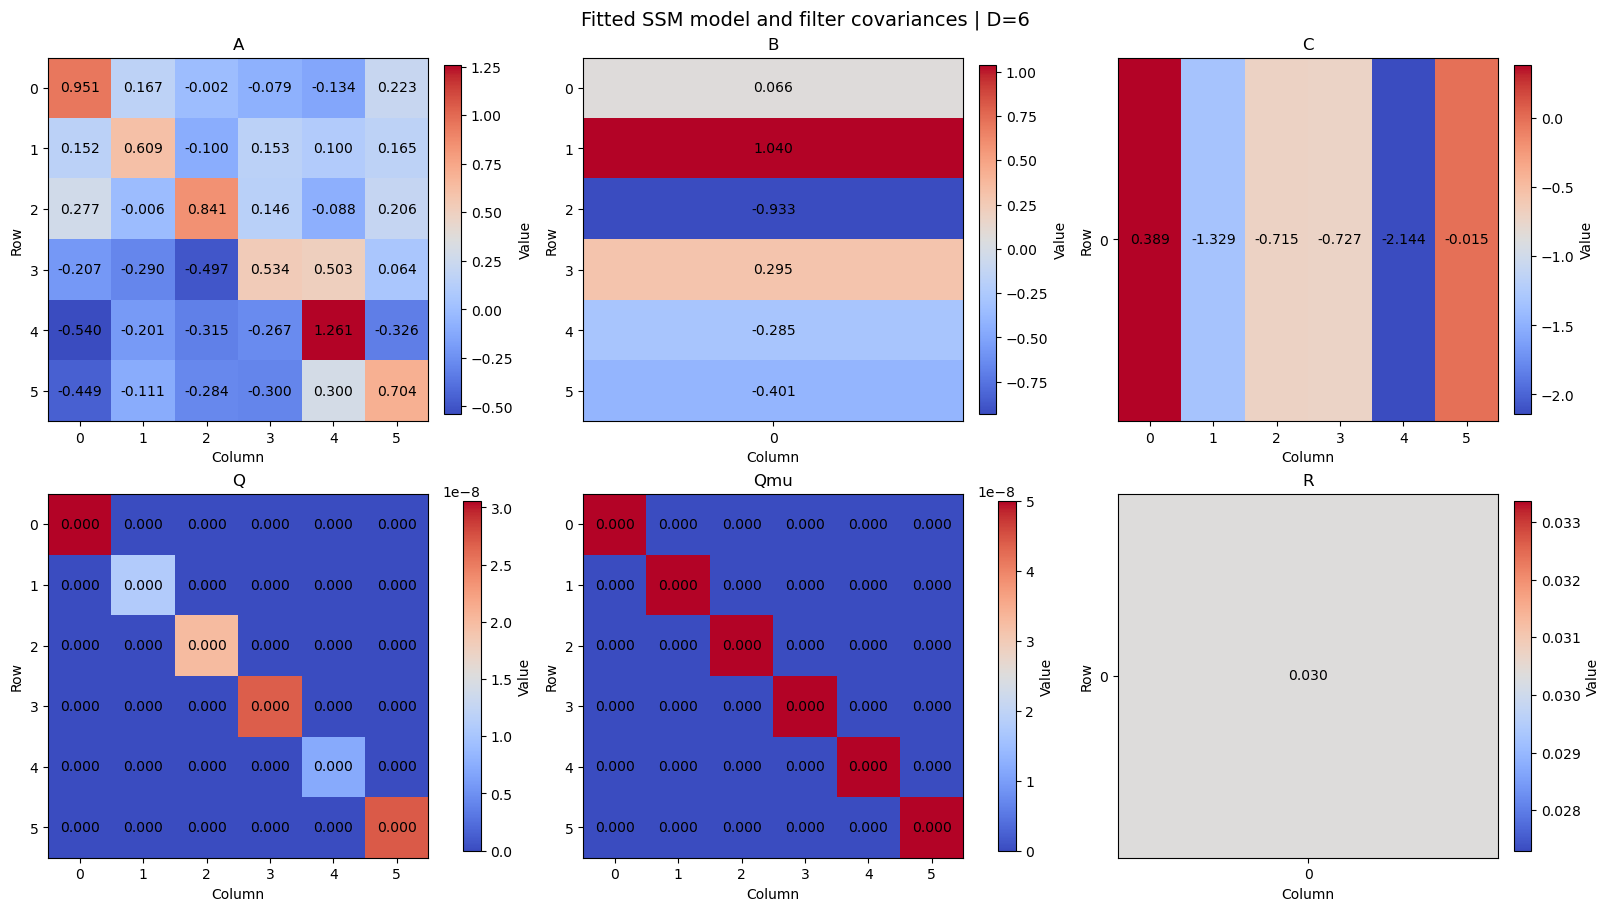

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

plot_model_matrix_grid(np.asarray(fitted_params["A"], dtype=float), "A", ax=axes[0, 0])
plot_model_matrix_grid(np.asarray(fitted_params["B"], dtype=float), "B", ax=axes[0, 1])
plot_model_matrix_grid(np.asarray(fitted_params["C"], dtype=float), "C", ax=axes[0, 2])

plot_model_matrix_grid(np.asarray(Q_matrix, dtype=float), "Q", ax=axes[1, 0])
plot_model_matrix_grid(np.asarray(Qmu_matrix, dtype=float), "Qmu", ax=axes[1, 1])
plot_model_matrix_grid(np.asarray(R_matrix, dtype=float), "R", ax=axes[1, 2])

fig.suptitle(f"Fitted SSM model and filter covariances | D={SSM_FIT_D}", fontsize=14)
plt.show()


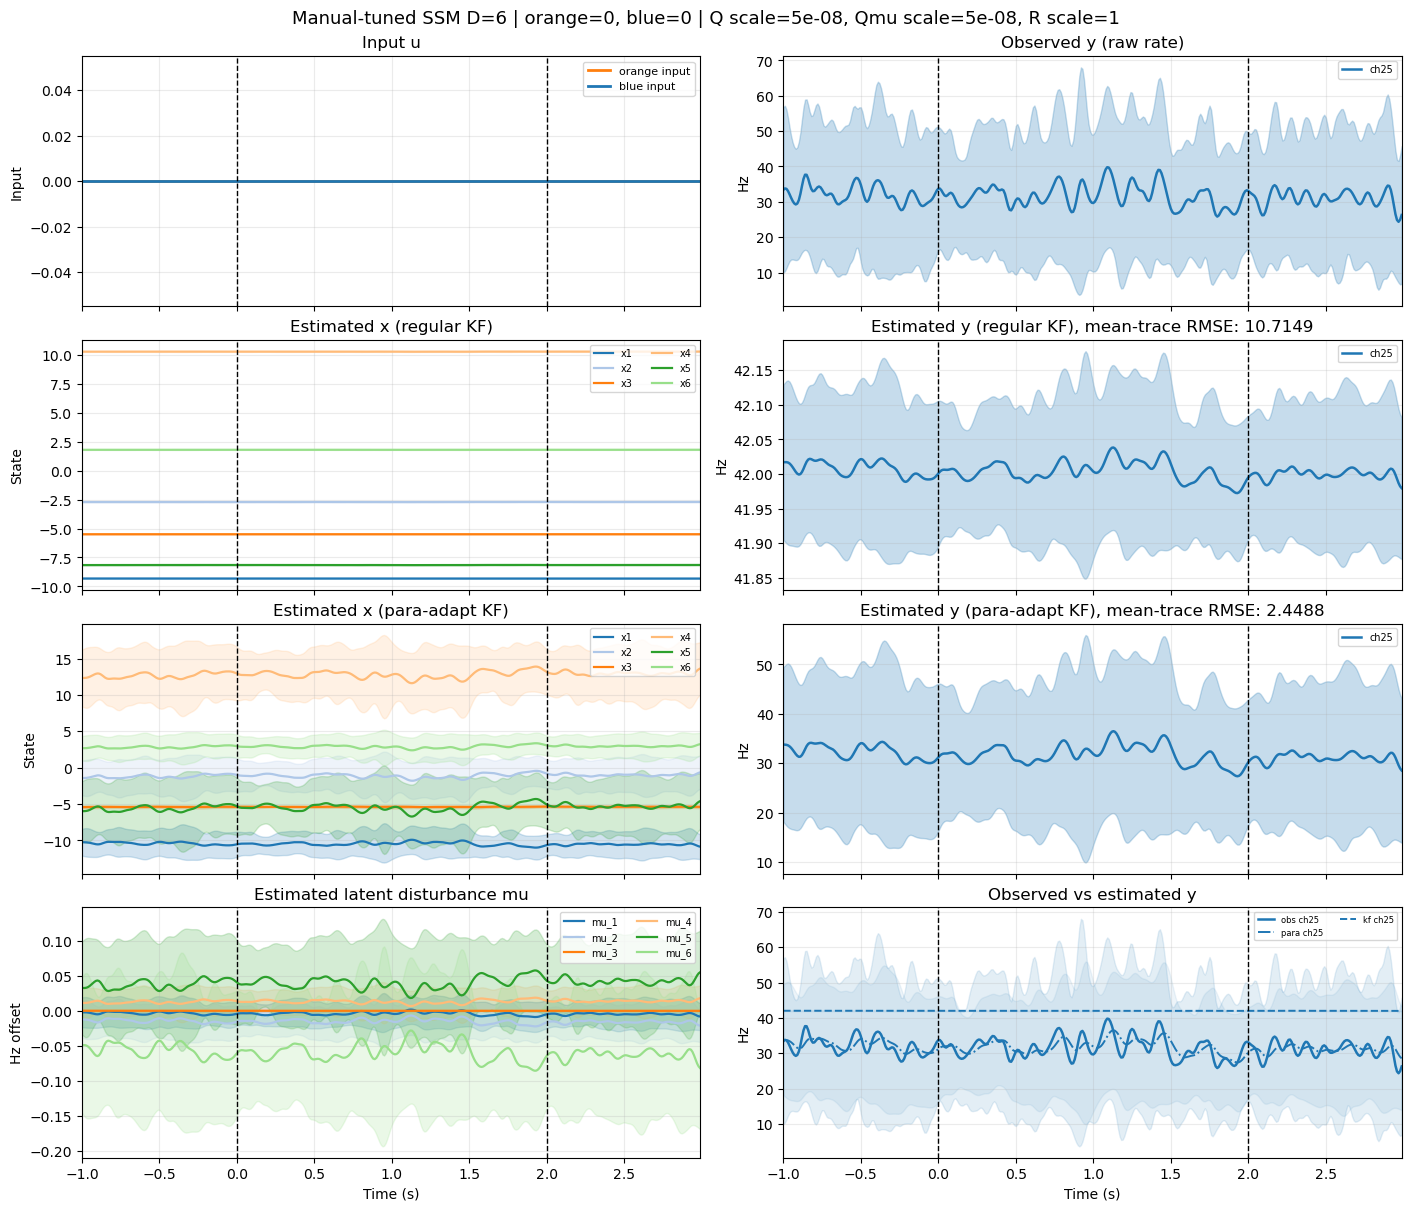

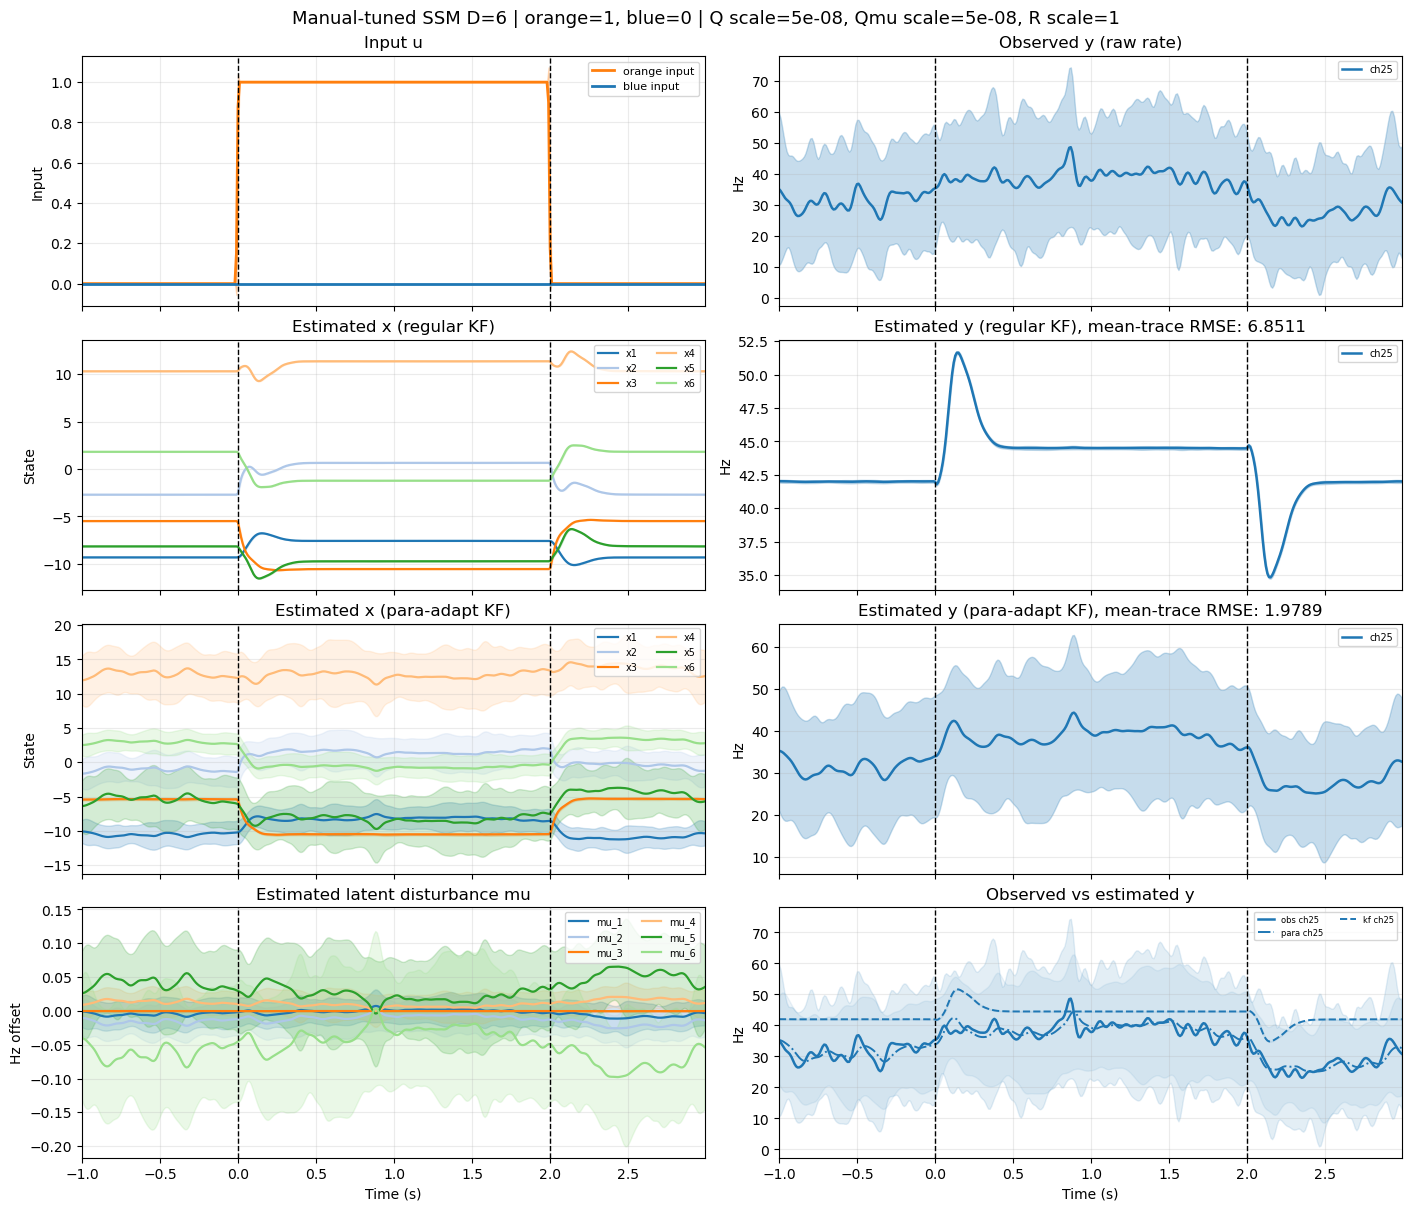

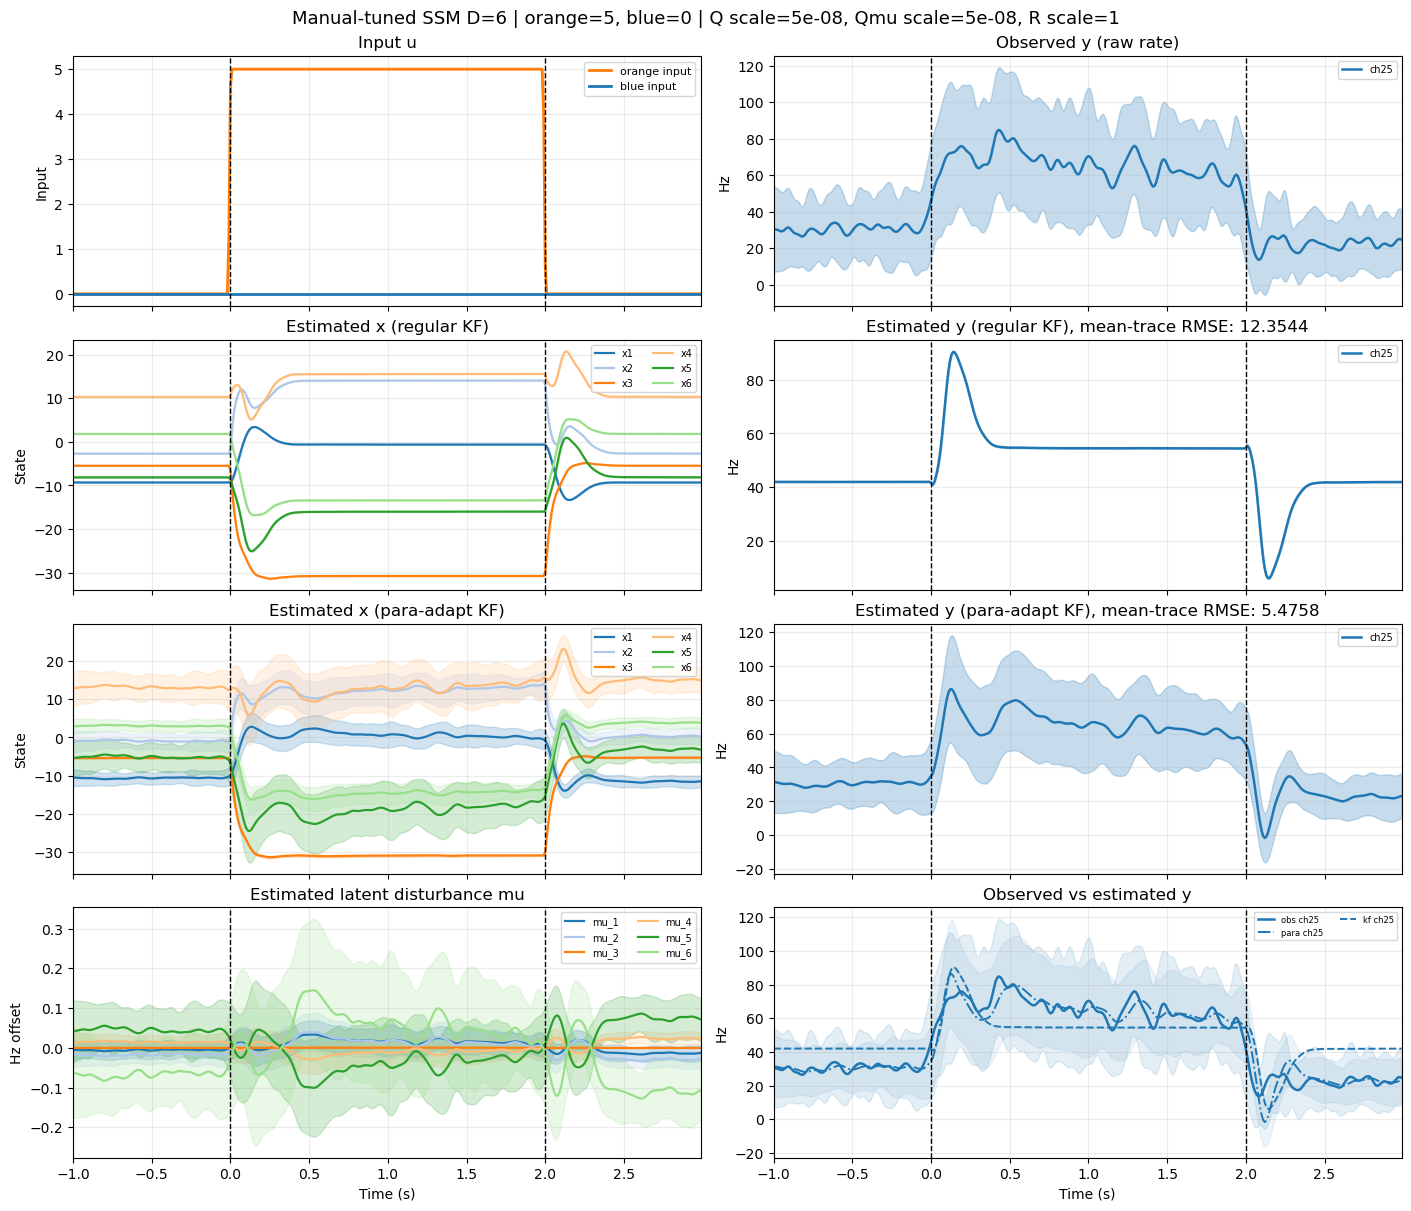

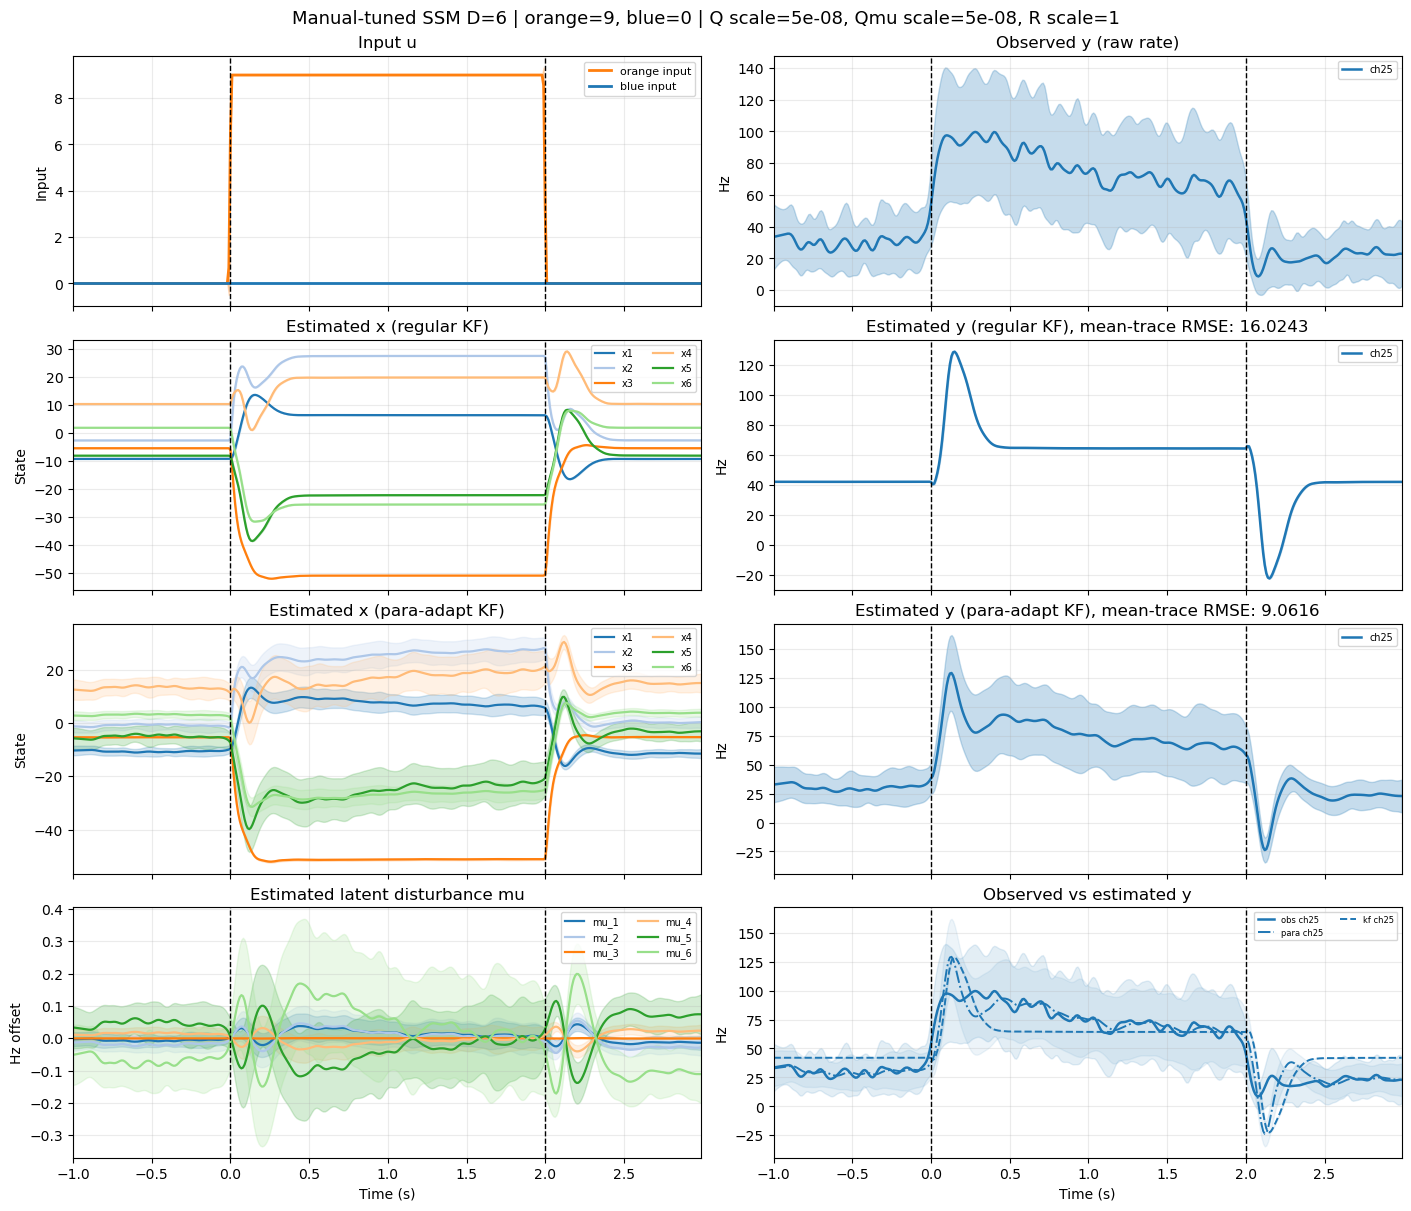

In [39]:
section4_combo_order = [(0.0, 0.0), (1.0, 0.0), (5.0, 0.0), (9.0, 0.0)]

for orange_level, blue_level in section4_combo_order:
    combo_results = [
        result for result in manual_step_results
        if float(result["orange_level"]) == float(orange_level)
        and float(result["blue_level"]) == float(blue_level)
    ]
    fig = plot_combo_trial_average_summary(
        combo_results=combo_results,
        channel_labels=list(FITTED_CHANNEL_LABELS),
    )
    fig.suptitle(
        f"Manual-tuned SSM D={SSM_FIT_D}"
        f" | orange={int(orange_level)}, blue={int(blue_level)}"
        f" | Q scale={MANUAL_Q_SCALE:g}, Qmu scale={MANUAL_QMU_SCALE:g}, R scale={MANUAL_R_SCALE:g}",
        fontsize=13,
    )
    plt.show()


C:\Users\jxiao85\AppData\Local\Temp\ipykernel_16720\1171457489.py:446: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  left_box = axes[0].boxplot(


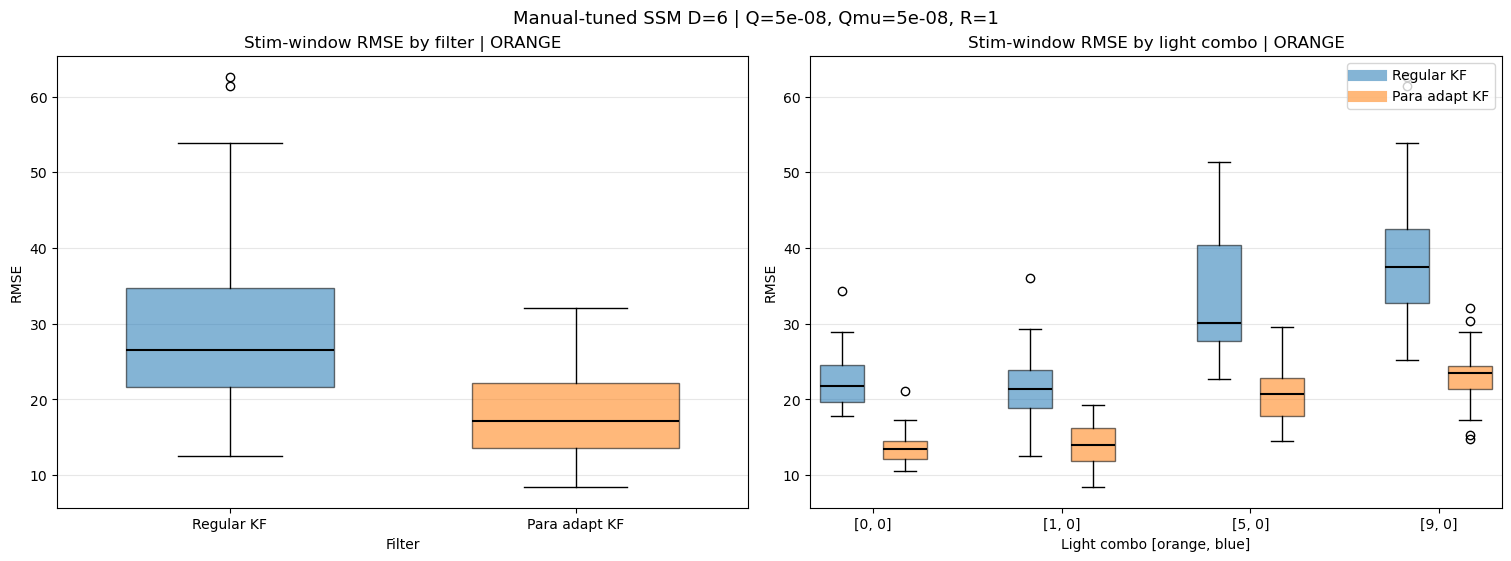

,orange_level,blue_level,file_number,trial_index,kf_rmse_stim,para_rmse_stim,rmse_gain_stim_kf_minus_para
0,0.0,0.0,5,31,26.674784,11.400569,15.274215
1,0.0,0.0,5,54,34.367105,21.138084,13.229020
2,0.0,0.0,5,57,19.486355,13.273036,6.213319
3,0.0,0.0,5,61,17.798969,14.305116,3.493853
4,0.0,0.0,6,31,26.488633,14.462505,12.026127


Section 5 light mode: ORANGE
Trials in grouped stats: 160
Mean KF RMSE: 28.980175348554134
Mean para RMSE: 17.84616537270109
Mean gain (KF - para): 11.134009975853042


In [40]:
manual_section5_fig, manual_section5_filtered_df = plot_group_rmse_stats(
    manual_batch_df,
    light_mode="ORANGE",
)

manual_section5_fig.suptitle(
    f"Manual-tuned SSM D={SSM_FIT_D}"
    f" | Q={MANUAL_Q_SCALE:g}, Qmu={MANUAL_QMU_SCALE:g}, R={MANUAL_R_SCALE:g}",
    fontsize=13,
)
plt.show()

display(
    manual_section5_filtered_df[
        [
            "orange_level",
            "blue_level",
            "file_number",
            "trial_index",
            "kf_rmse_stim",
            "para_rmse_stim",
            "rmse_gain_stim_kf_minus_para",
        ]
    ].head()
)

print("Section 5 light mode: ORANGE")
print("Trials in grouped stats:", len(manual_section5_filtered_df))
print("Mean KF RMSE:", manual_section5_filtered_df["kf_rmse_stim"].mean())
print("Mean para RMSE:", manual_section5_filtered_df["para_rmse_stim"].mean())
print("Mean gain (KF - para):", manual_section5_filtered_df["rmse_gain_stim_kf_minus_para"].mean())
